
# <span style="color:rgb(213,80,0)">Delta and Adaptive delta modulation</span>

In [1]:
% clc;
clear;

fm = 10;
fs = 500;

t = 0:1/fs:1;
x = sin(2*pi*fm*t);

delta = 0.1; %step size
N = length(x);

x_hat = zeros(1,N);
dm_bits = zeros(1,N); %delta modulated bits


## delta modulation

In [2]:
for n= 2:N
    if x(n) >= x_hat(n-1)

        dm_bits(n) = 1;
        x_hat(n) = x_hat(n-1)+delta;
    else
        dm_bits(n) = 0;
        x_hat(n) = x_hat(n-1)-delta;
    end
end

## plot original and reconstructed signal


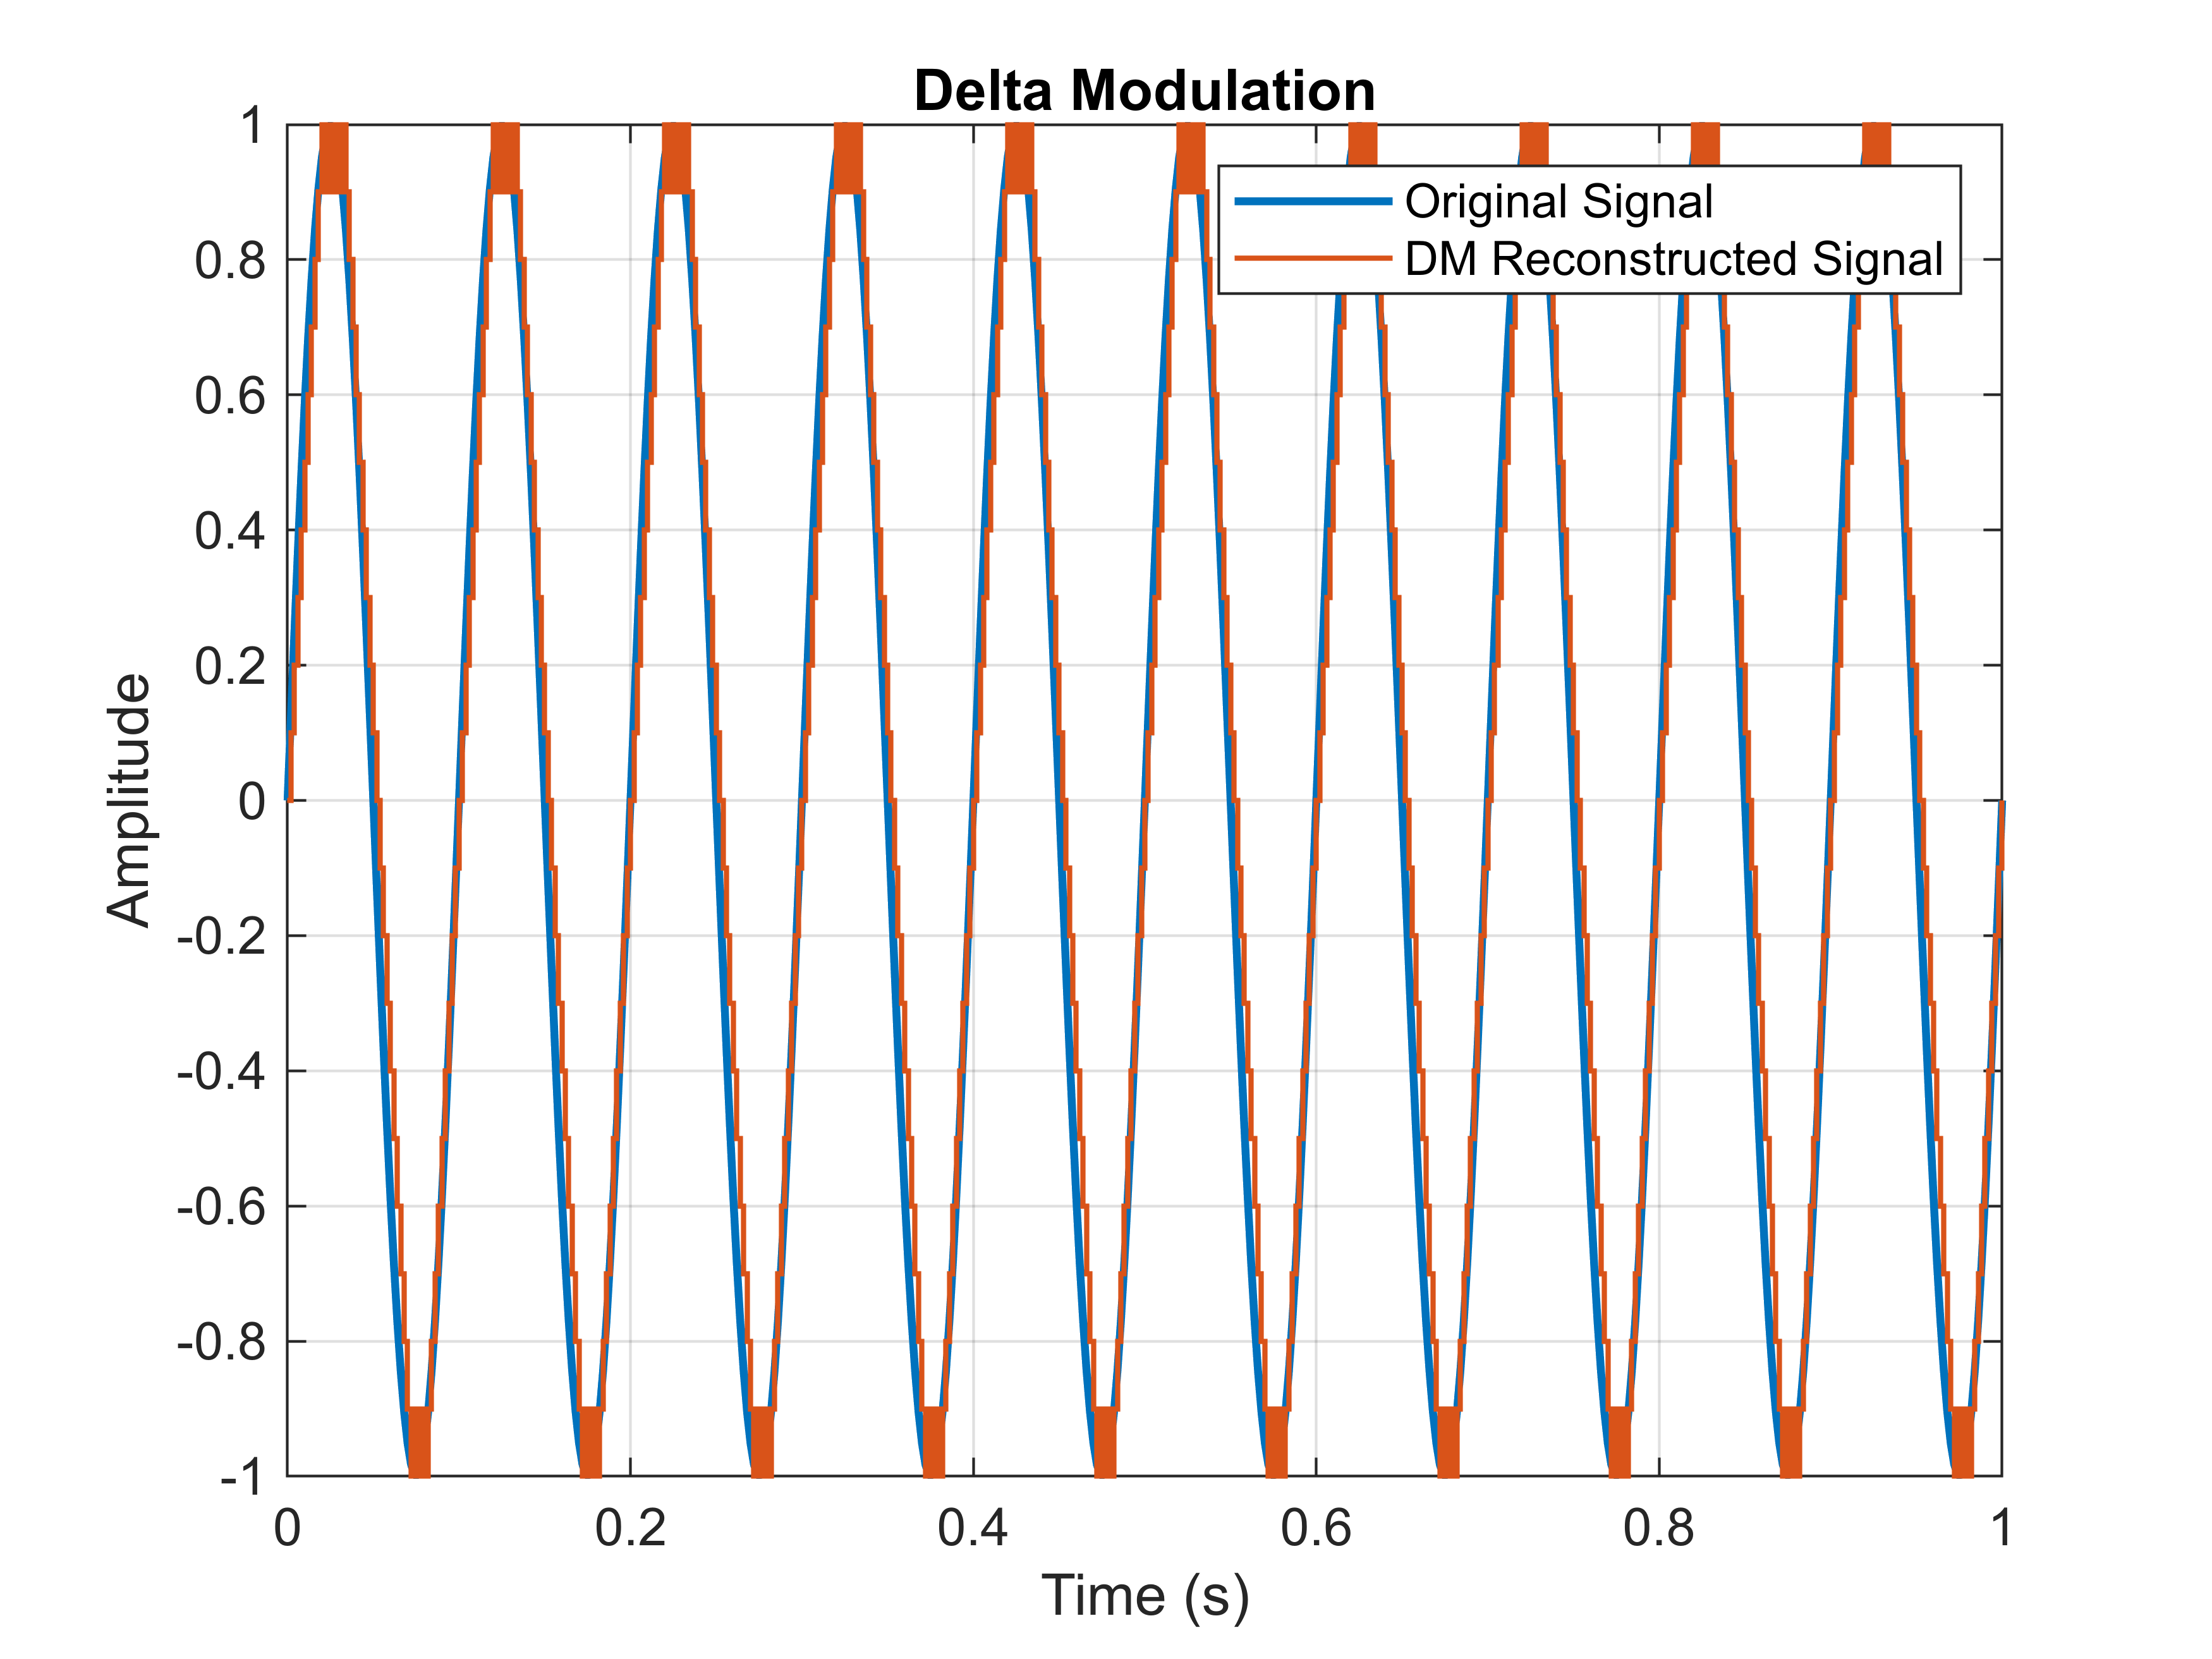

In [3]:
%% Plot original and reconstructed signal

figure;

plot(t,x,'LineWidth',1.5);
hold on;

stairs(t,x_hat,'LineWidth',1.0);

xlabel('Time (s)');
ylabel('Amplitude');

title('Delta Modulation');

legend('Original Signal','DM Reconstructed Signal');

grid on;


## Plot DM bit stream


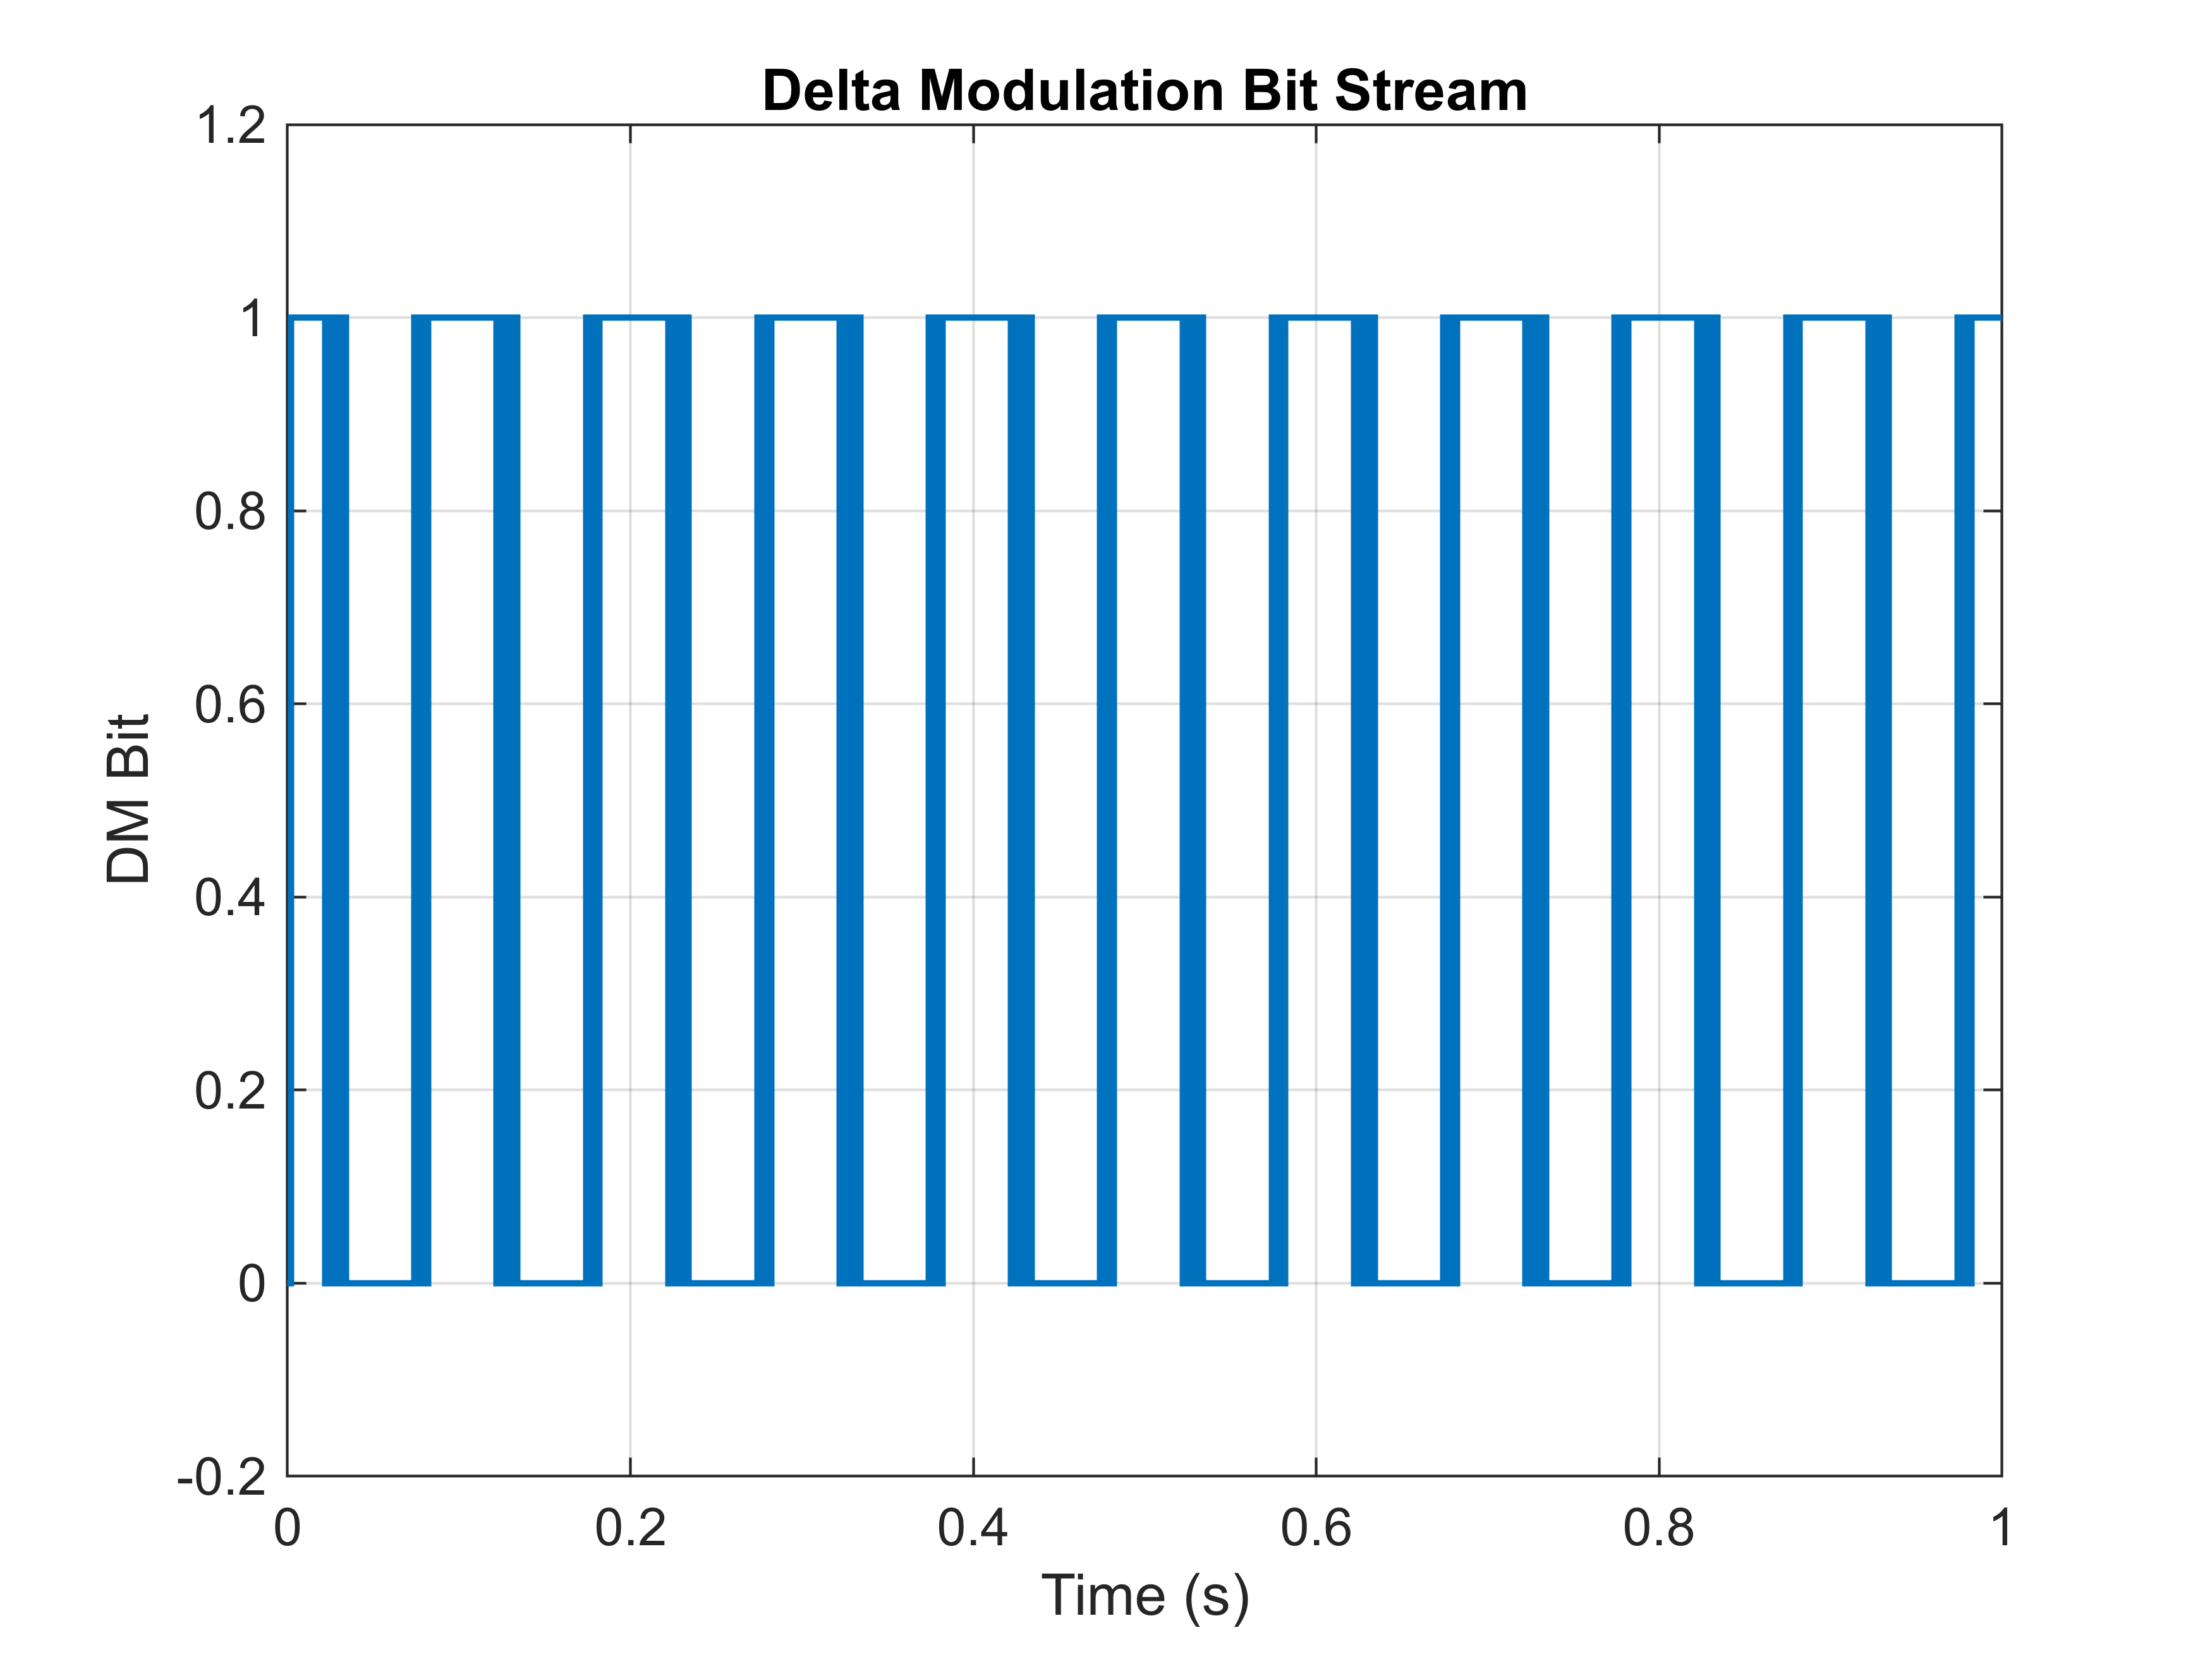

In [4]:
figure;

stairs(t,dm_bits,'LineWidth',1.2);

ylim([-0.2 1.2]);

xlabel('Time (s)');
ylabel('DM Bit');

title('Delta Modulation Bit Stream');

grid on;

## Adaptive Delta Modulation


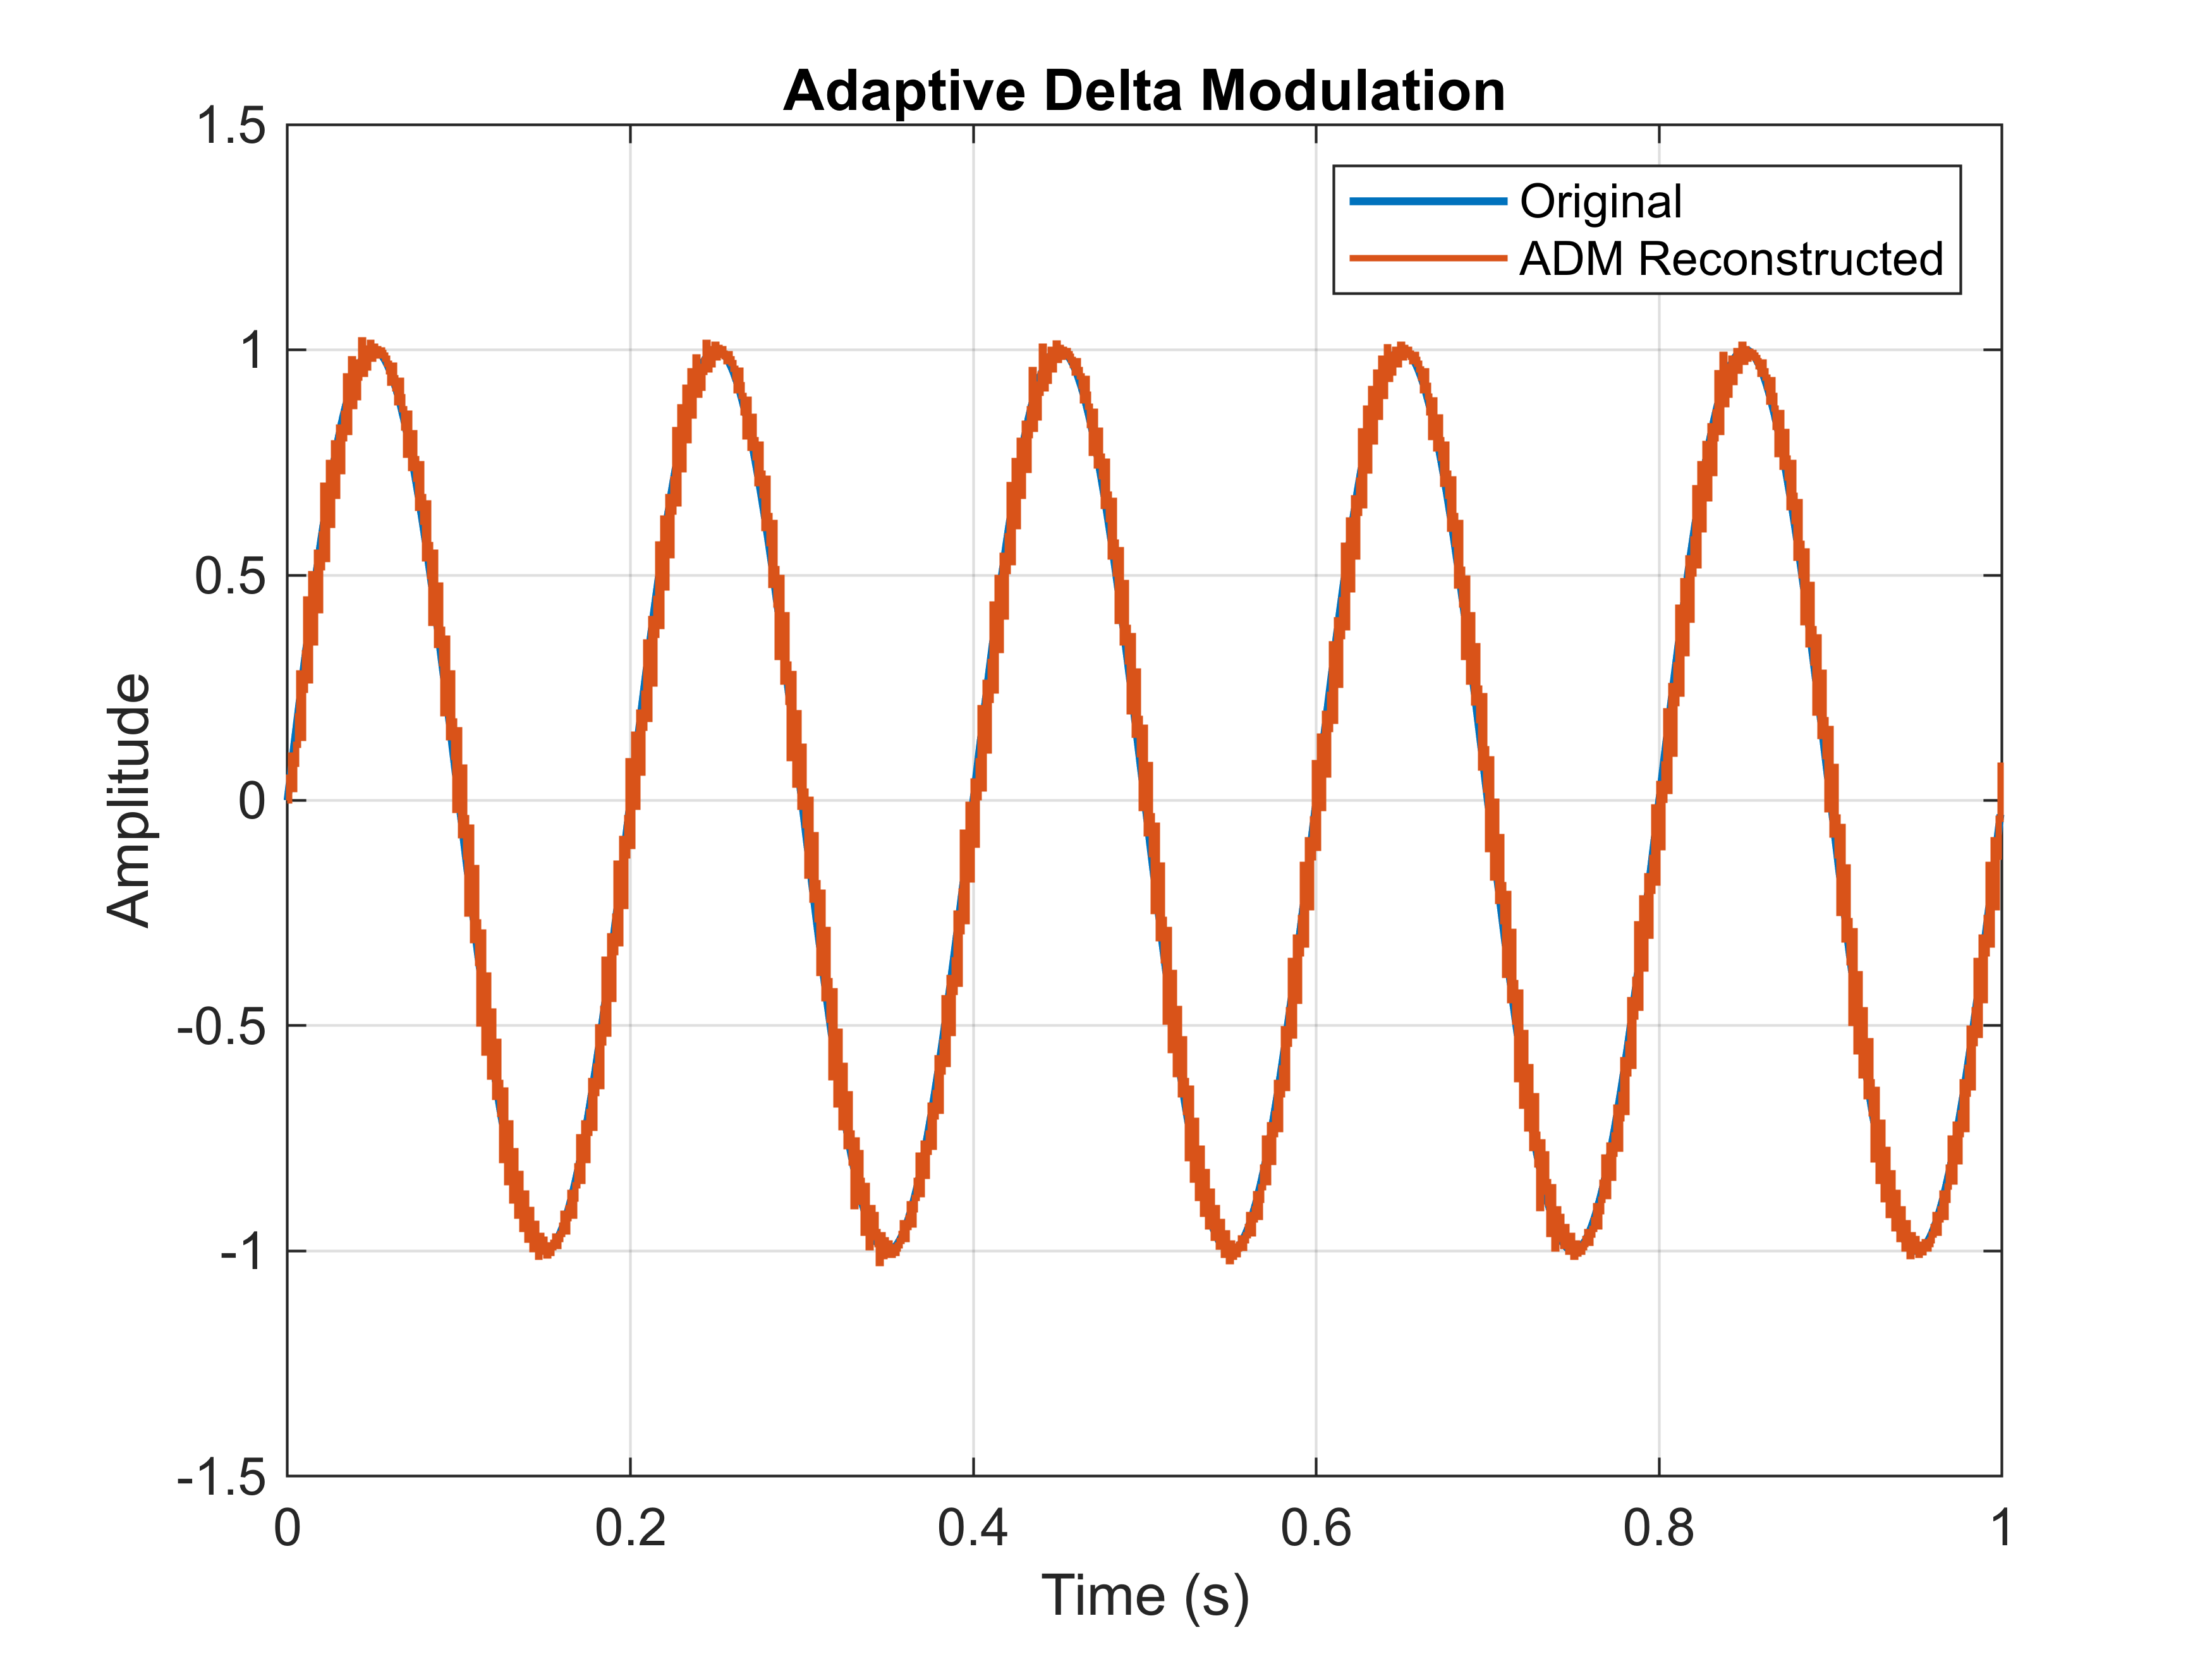

In [5]:
clc;
clear;
close all;

%% Message signal
fs = 1000;
fm = 5;

t = 0:1/fs:1-1/fs;

x = sin(2*pi*fm*t);

%% Adaptive Delta parameters

Delta = 0.05;       % Initial step size

Delta_min = 0.005;  % Minimum step
Delta_max = 0.3;    % Maximum step

alpha = 1.5;        % Increase factor
beta = 0.75;        % Decrease factor

%% Initialization

N = length(x);

x_hat = zeros(1,N);
dm_bits = zeros(1,N);
Delta_history = zeros(1,N);

%% Adaptive Delta Modulation

for n = 2:N

    if x(n) >= x_hat(n-1)

        dm_bits(n) = 1;

        x_hat(n) = x_hat(n-1) + Delta;

    else

        dm_bits(n) = 0;

        x_hat(n) = x_hat(n-1) - Delta;

    end

    %% Adapt Delta

    if n >= 3

        if dm_bits(n) == dm_bits(n-1)

            % Same direction repeatedly
            % Signal is changing rapidly

            Delta = min(alpha*Delta, Delta_max);

        else

            % Direction changed
            % Signal is changing slowly

            Delta = max(beta*Delta, Delta_min);

        end

    end

    Delta_history(n) = Delta;

end

%% Original vs reconstructed

figure;

plot(t,x,'LineWidth',1.5);
hold on;

stairs(t,x_hat,'LineWidth',1.2);

xlabel('Time (s)');
ylabel('Amplitude');

title('Adaptive Delta Modulation');

legend('Original','ADM Reconstructed');

grid on;


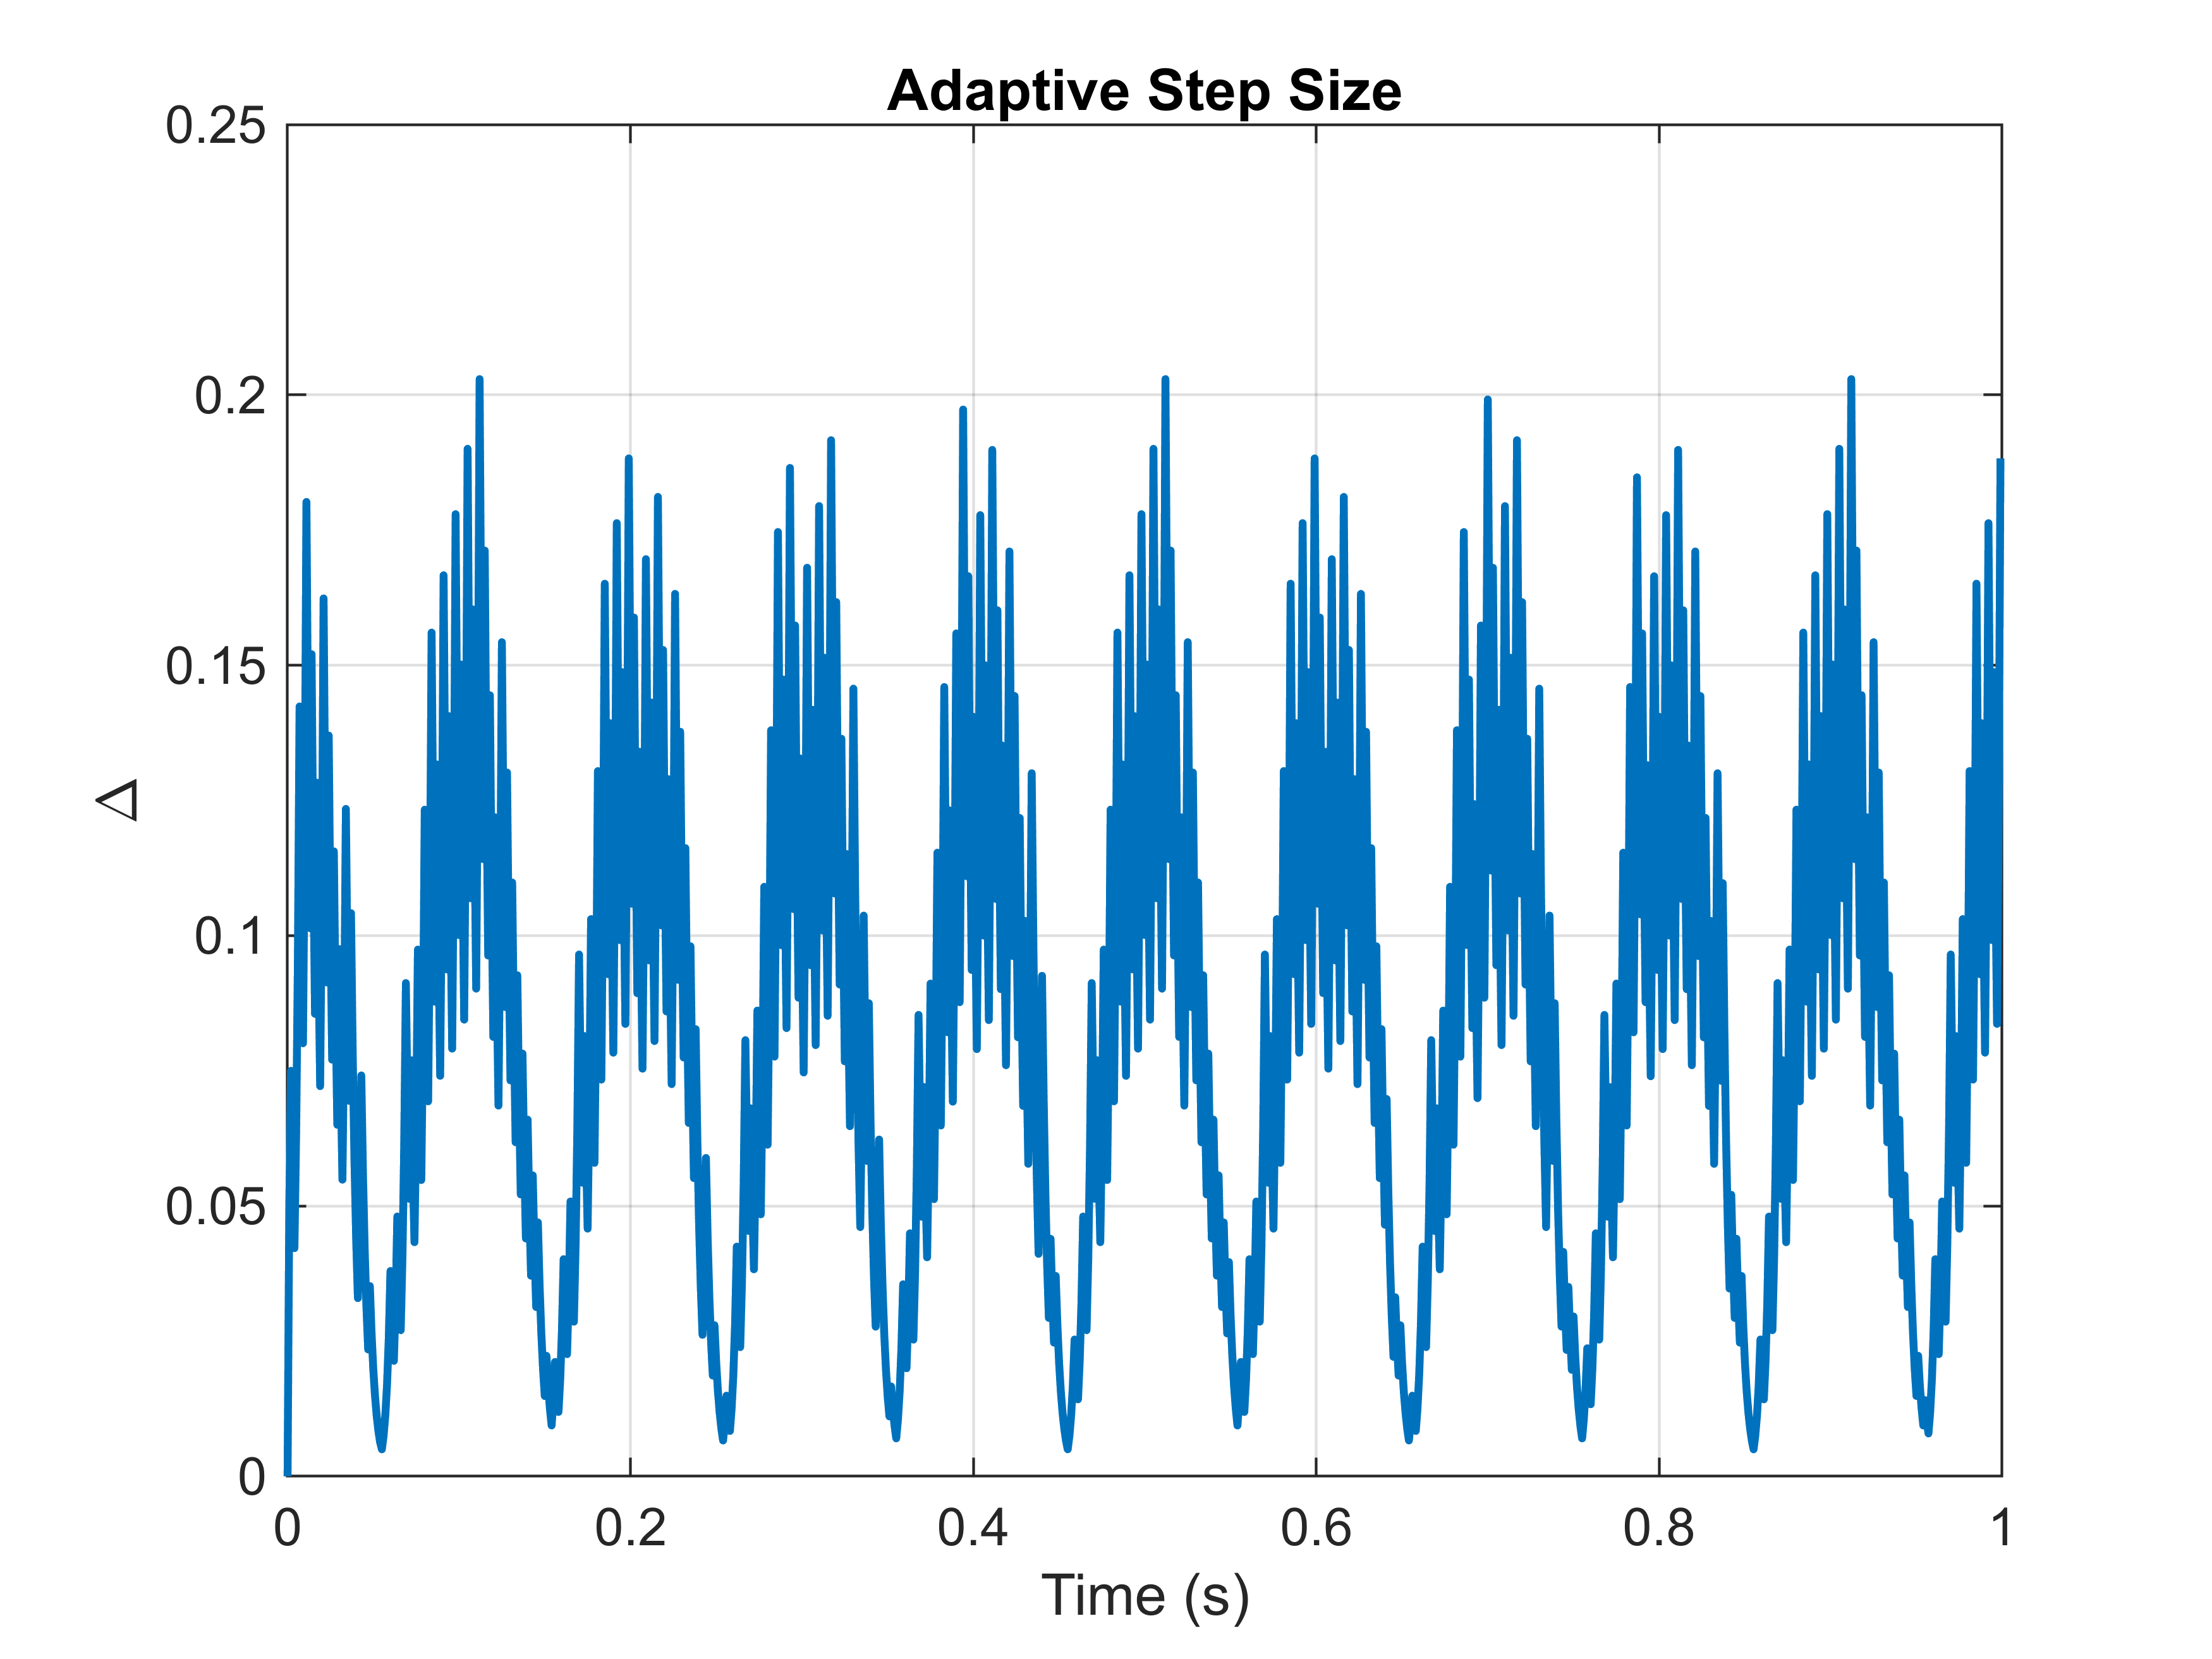

In [6]:

%% Step size variation

figure;

plot(t,Delta_history,'LineWidth',1.5);

xlabel('Time (s)');
ylabel('\Delta');

title('Adaptive Step Size');

grid on;


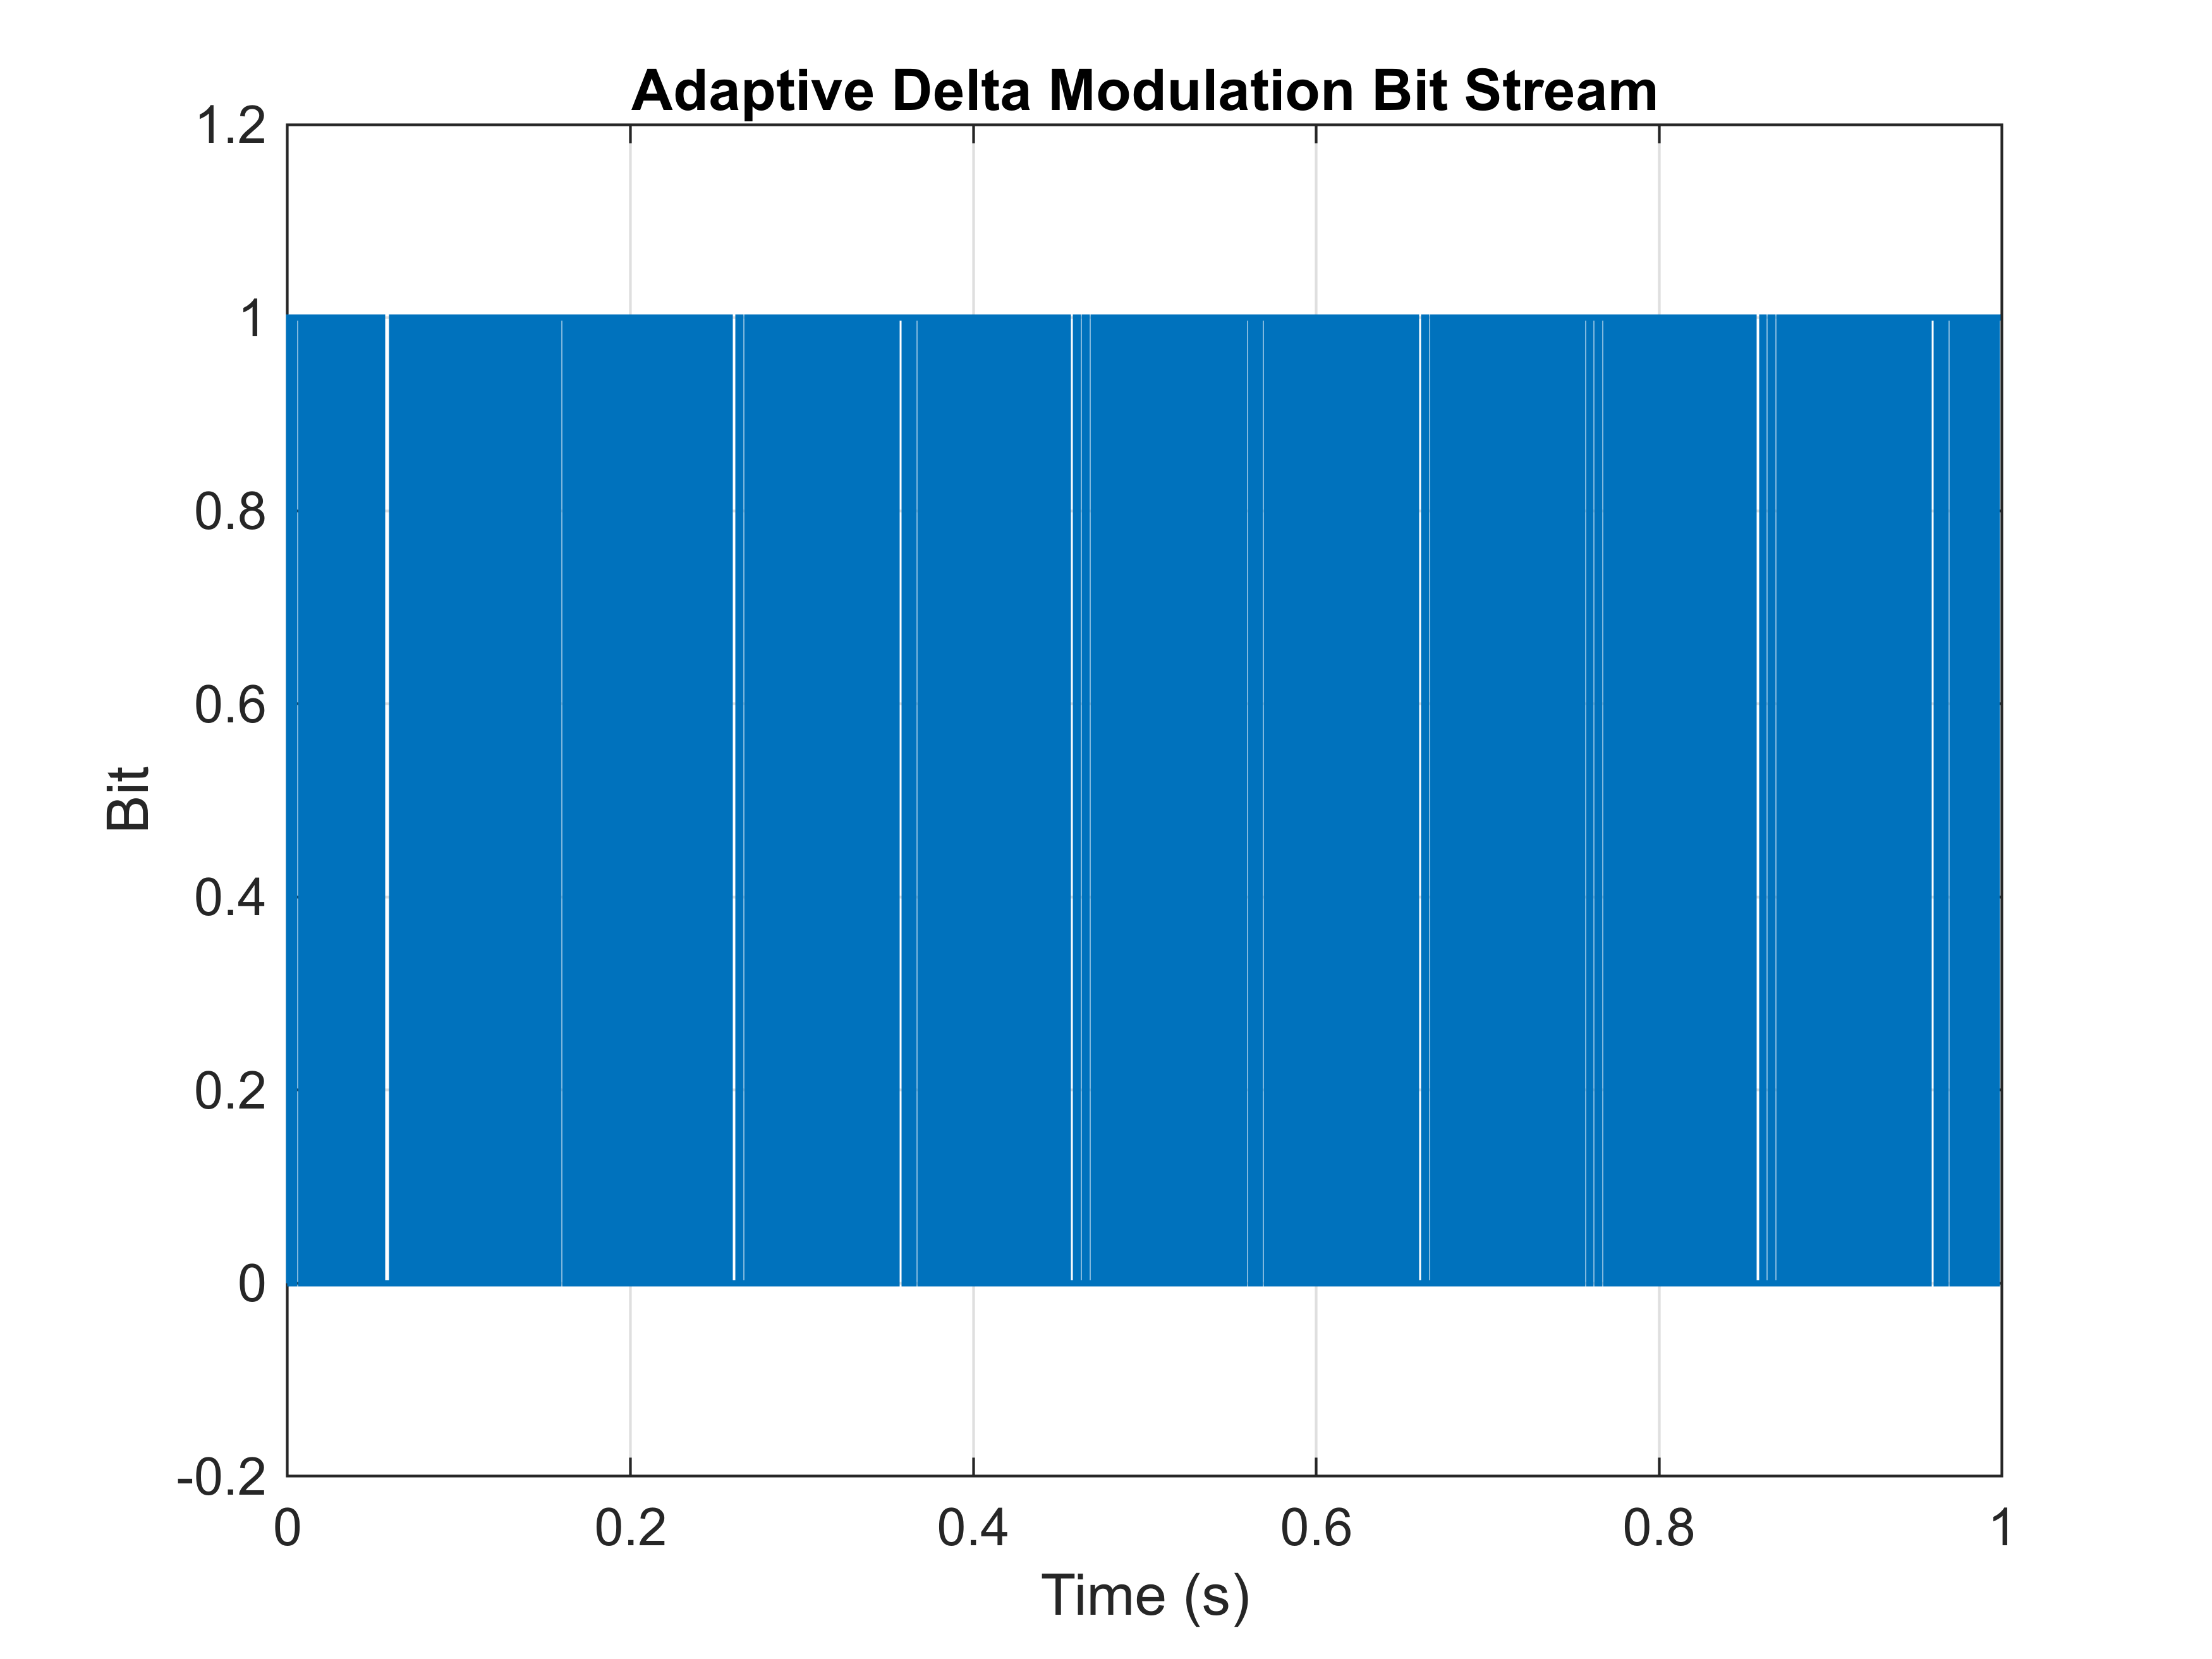

In [7]:

%% ADM bit stream

figure;

stairs(t,dm_bits,'LineWidth',1.2);

ylim([-0.2 1.2]);

xlabel('Time (s)');
ylabel('Bit');

title('Adaptive Delta Modulation Bit Stream');

grid on;